# Car Damage Detection using CarDD Dataset

Automatic car damage detection is a critical problem in the insurance industry.
Accurate localization and classification of car damage can significantly reduce
manual inspection costs and accelerate claim processing.

In this notebook, we train a deep learning object detection model using the
Car Damage Detection (CarDD) dataset.

CarDD contains:
- ~4,000 high-resolution images
- Over 9,000 annotated instances
- Six damage categories
- COCO-format annotations

We use:

- Faster R-CNN with ResNet50-FPN backbone
- Transfer learning from COCO-pretrained weights
- Data augmentation
- Fine-tuning of the backbone
- COCO mAP evaluation
- Bounding box visualization

The final trained model will later be integrated into a Streamlit + LLM
application for automated insurance damage assessment.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp -r /content/drive/MyDrive/01_Data /content/

## 1. Import Libraries

Import necessary packages for training, evaluation, and visualization.

In [4]:
import os
import torch
import torchvision
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from torch.utils.data import DataLoader
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

from tqdm import tqdm

## 2. Configure Device

Use GPU if available for faster training.

In [5]:
# Checking Device Configuracion
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Using device:", device)

Using device: cuda


## 3. Dataset Structure

The dataset follows COCO format:

- train2017/
- val2017/
- test2017/
- annotations/
    - instances_train2017.json
    - instances_val2017.json
    - instances_test2017.json

In [6]:
# Data Path
#DATA_ROOT = os.getcwd().replace("02_Training", "01_Data")
DATA_ROOT = "/content/01_Data"

TRAIN_IMG = os.path.join(DATA_ROOT, "train2017")
VAL_IMG = os.path.join(DATA_ROOT, "val2017")
TEST_IMG = os.path.join(DATA_ROOT, "test2017")

TRAIN_ANN = os.path.join(DATA_ROOT, "annotations", "instances_train2017.json")
VAL_ANN = os.path.join(DATA_ROOT, "annotations", "instances_val2017.json")
TEST_ANN = os.path.join(DATA_ROOT, "annotations", "instances_test2017.json")

## 4. Custom Dataset Class

We extend `CocoDetection` to:

- Convert bounding boxes to [x1, y1, x2, y2]
- Convert images to tensors
- Apply safe data augmentation

In [7]:
class CarDDDataset(CocoDetection):
    def __init__(self, img_folder, ann_file, train=True):
        super().__init__(img_folder, ann_file)
        self.train = train

    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)

        boxes = []
        labels = []

        for obj in target:
            x, y, w, h = obj["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(obj["category_id"])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        img = F.to_tensor(img)

        # Data augmentation
        if self.train:
            if random.random() > 0.5:
                img = torch.flip(img, dims=[2])
                w = img.shape[2]
                boxes[:, [0, 2]] = w - boxes[:, [2, 0]]

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        return img, target

## 5. Create DataLoaders

In [8]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = CarDDDataset(TRAIN_IMG, TRAIN_ANN, train=True)
val_dataset = CarDDDataset(VAL_IMG, VAL_ANN, train=False)
test_dataset = CarDDDataset(TEST_IMG, TEST_ANN, train=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

loading annotations into memory...
Done (t=0.21s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


## 6. Initialize Faster R-CNN

We load COCO-pretrained weights and replace the classification head.

In [9]:
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# Load number of categories from COCO file
coco = COCO(TRAIN_ANN)
num_classes = len(coco.getCatIds()) + 1  # + background

model = get_model(num_classes)
model.to(device)

loading annotations into memory...
Done (t=0.20s)
creating index...
index created!
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:02<00:00, 62.8MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## 7. Phase 1 Training (Frozen Backbone)

In [11]:
for param in model.backbone.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.0005
)

## 8. Training with Early Stopping

In [12]:
num_epochs = 20
patience = 3
best_val_loss = float("inf")
patience_counter = 0

def evaluate_loss(model, loader):
    model.train()
    total_loss = 0
    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            total_loss += sum(loss for loss in loss_dict.values()).item()
    return total_loss

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for images, targets in tqdm(train_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        train_loss += losses.item()

    val_loss = evaluate_loss(model, val_loader)

    print(f"Epoch {epoch+1}")
    print("Train Loss:", train_loss)
    print("Val Loss:", val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_phase1.pth")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping.")
        break

100%|██████████| 704/704 [08:45<00:00,  1.34it/s]


Epoch 1
Train Loss: 270.8666629642248
Val Loss: 70.73140198737383


100%|██████████| 704/704 [08:50<00:00,  1.33it/s]


Epoch 2
Train Loss: 244.70436795055866
Val Loss: 71.10402753204107


100%|██████████| 704/704 [08:49<00:00,  1.33it/s]


...

Epoch 4
Train Loss: 232.91352056711912
Val Loss: 69.59090192615986


100%|██████████| 704/704 [08:47<00:00,  1.34it/s]


Epoch 5
Train Loss: 227.9041901603341
Val Loss: 69.24802983552217


100%|██████████| 704/704 [08:47<00:00,  1.33it/s]


Epoch 6
Train Loss: 223.21487484127283
Val Loss: 68.47554060071707
Early stopping.


## 9. Phase 2: Fine-Tuning Full Network

We unfreeze the backbone and fine-tune with a lower learning rate.

In [13]:
model.load_state_dict(torch.load("best_phase1.pth"))

for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, targets in tqdm(train_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    print(f"Fine-Tuning Epoch {epoch+1}, Loss: {total_loss}")

torch.save(model.state_dict(), "best_carDD_model.pth")

100%|██████████| 704/704 [18:53<00:00,  1.61s/it]


Fine-Tuning Epoch 1, Loss: 221.83982434868813


100%|██████████| 704/704 [18:52<00:00,  1.61s/it]


Fine-Tuning Epoch 2, Loss: 212.04922189563513


100%|██████████| 704/704 [18:52<00:00,  1.61s/it]


Fine-Tuning Epoch 3, Loss: 205.82624706625938


100%|██████████| 704/704 [18:27<00:00,  1.57s/it]


Fine-Tuning Epoch 4, Loss: 195.2395011037588


100%|██████████| 704/704 [18:17<00:00,  1.56s/it]


Fine-Tuning Epoch 5, Loss: 187.3892475143075


## 10. Evaluate using COCO mAP

In [17]:
def compute_map(model, dataset, annotation_file):
    model.eval()
    coco_gt = COCO(annotation_file)
    coco_dt_list = []

    for idx in range(len(dataset)):
        img, _ = dataset[idx]
        img = img.to(device)

        image_id = dataset.ids[idx]

        with torch.no_grad():
            prediction = model([img])[0]

        boxes = prediction["boxes"].cpu().numpy()
        scores = prediction["scores"].cpu().numpy()
        labels = prediction["labels"].cpu().numpy()

        for box, score, label in zip(boxes, scores, labels):
            if score < 0.5:
                continue

            x1, y1, x2, y2 = box
            coco_dt_list.append({
                "image_id": image_id,
                "category_id": int(label),
                "bbox": [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                "score": float(score)
            })

    coco_dt = coco_gt.loadRes(coco_dt_list)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")

    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

compute_map(model, val_dataset, VAL_ANN)

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.50s).
Accumulating evaluation results...
DONE (t=0.13s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.357
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.563
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.383
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.069
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.096
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.359
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.415
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.475
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

## 11. Visualize Predictions

loading annotations into memory...
Done (t=0.08s)
creating index...
index created!


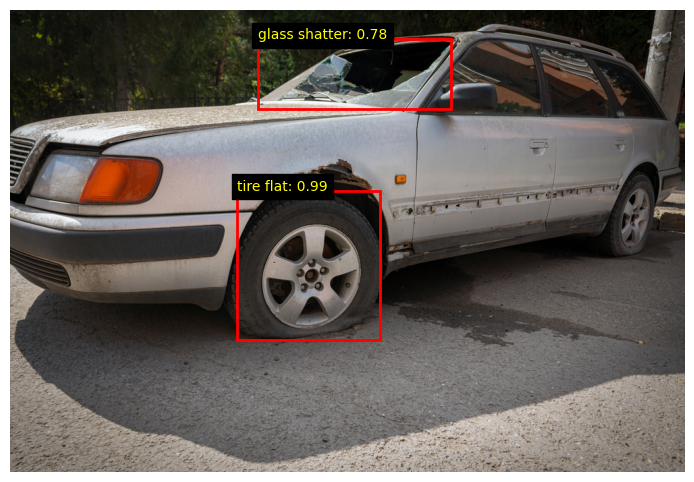

In [19]:
model.eval()
img, _ = val_dataset[0]
img_tensor = img.to(device)

with torch.no_grad():
    prediction = model([img_tensor])[0]

# Build category id → name mapping
coco = COCO(VAL_ANN)
cat_ids = coco.getCatIds()
cats = coco.loadCats(cat_ids)
id_to_name = {cat["id"]: cat["name"] for cat in cats}

fig, ax = plt.subplots(1, figsize=(10, 6))
ax.imshow(img.permute(1, 2, 0))

for box, score, label in zip(
        prediction["boxes"],
        prediction["scores"],
        prediction["labels"]):

    if score < 0.5:
        continue

    x1, y1, x2, y2 = box.cpu().numpy()

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

    class_name = id_to_name.get(int(label), "Unknown")

    ax.text(
        x1,
        y1,
        f"{class_name}: {score:.2f}",
        color='yellow',
        fontsize=10,
        bbox=dict(facecolor='black')
    )

plt.axis("off")
plt.show()

## Testing with a different Dataset

In [20]:
model = get_model(num_classes)
model.load_state_dict(torch.load("best_carDD_model.pth", map_location=device))
model.to(device)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

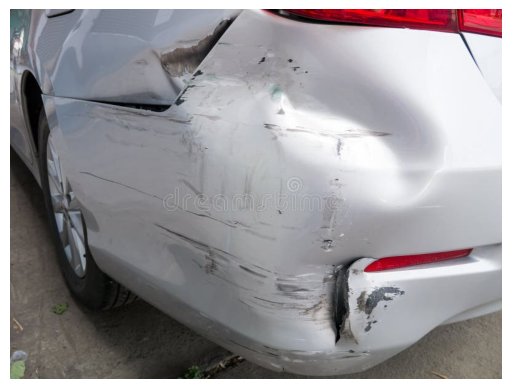

In [21]:
import requests
from PIL import Image
from io import BytesIO

url = "https://thumbs.dreamstime.com/b/car-bumper-damage-rear-37793860.jpg"

response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

In [22]:
# Preprocessing Internet Image
from torchvision.transforms import functional as F

img_tensor = F.to_tensor(image).to(device)

In [23]:
# Running Inference
with torch.no_grad():
    prediction = model([img_tensor])[0]

In [24]:
# Map Category ID to Names
from pycocotools.coco import COCO

coco = COCO(TRAIN_ANN)
cat_ids = coco.getCatIds()
cats = coco.loadCats(cat_ids)
id_to_name = {cat["id"]: cat["name"] for cat in cats}

loading annotations into memory...
Done (t=0.54s)
creating index...
index created!


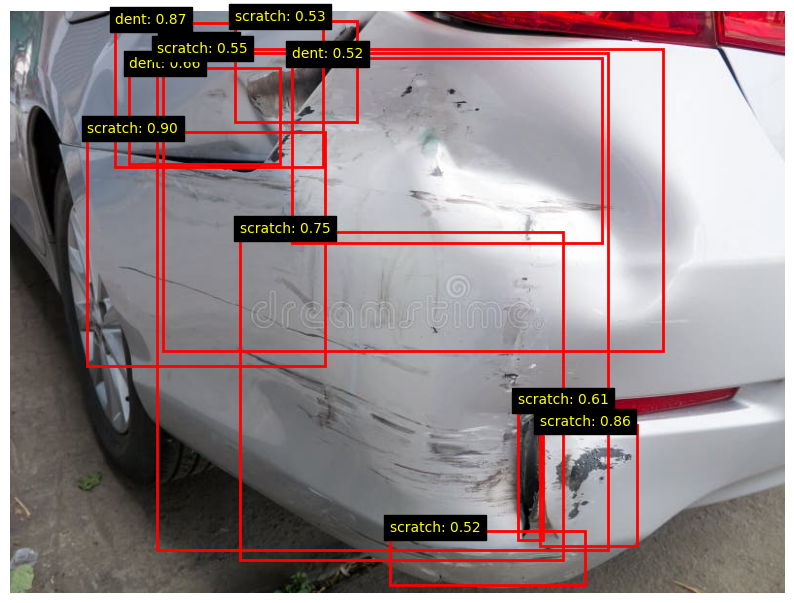

In [25]:
import matplotlib.patches as patches

threshold = 0.5  # adjust if needed

fig, ax = plt.subplots(1, figsize=(10, 8))
ax.imshow(image)

for box, score, label in zip(
    prediction["boxes"],
    prediction["scores"],
    prediction["labels"]
):
    if score < threshold:
        continue

    x1, y1, x2, y2 = box.cpu().numpy()

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

    class_name = id_to_name.get(int(label), "Unknown")

    ax.text(
        x1,
        y1,
        f"{class_name}: {score:.2f}",
        color='yellow',
        fontsize=10,
        bbox=dict(facecolor='black')
    )

plt.axis("off")
plt.show()